<a href="https://colab.research.google.com/github/brishti-c/undergrad_ml_assignments/blob/main/05_assignment_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

They allow us to model nonlinear relationships between inputs and outputs while still keeping a simple linear structure underneath. A linear model predicts values directly, which can be inappropriate (e.g., probabilities outside [0,1]). Activation functions (like the logistic function) transform the linear combination into a valid output space (e.g., probabilities), making the model more flexible and realistic.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Binary and categorical cross entropy come from maximum likelihood estimation for probabilistic models. Logistic regression models probabilities, and cross-entropy directly measures how well the predicted probabilities match the true labels. It strongly penalizes confident wrong predictions, which helps the model learn better decision boundaries.

3. True or false, and explain: Logistic regression is a linear model.

It is linear in the parameters (weights), since it models a linear combination of features. However, the output is passed through a nonlinear function (sigmoid), so the predictions are nonlinear.

4. True or false, and explain: Logistic regression cannot be used for classification.

False. It is specifically designed for classification by converting probabilities into class labels (e.g., threshold at 0.5).

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No. In logistic regression, coefficients represent the change in the log-odds, not the raw predicted probability. The effect on probability depends on the current value of the input.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. Logistic regression is still linear in features. Without feature engineering (e.g., interactions, polynomials), it cannot capture complex relationships.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False. Logistic regression is better for classification, but linear regression is better for continuous outcomes. The choice depends on the problem.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

! git clone https://github.com/brishti-c/scratchpad
%run ./scratchpad/get_data.py

fatal: destination path 'scratchpad' already exists and is not an empty directory.


<Figure size 640x480 with 0 Axes>

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

The logistic regression coefficients show that Debtor (+0.53) and Age at enrollment (+0.05) increase dropout probability, while Tuition fees up to date (-2.56) and Scholarship holder (-1.23) decrease it. Being up to date on tuition has the strongest negative coefficient, meaning it substantially reduces dropout risk.

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

The scatter plot shows dropout risk increases with age for all students, but the gap between those not up to date on tuition (higher risk) and those up to date (lower risk) widens at older ages. Thus, being up to date reduces dropout probability most for older students. On average, being up to date lowers predicted dropout probability by a substantial margin (negative average effect).

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

The confusion matrix shows 2,841 true negatives, 162 false positives, 891 false negatives, and 530 true positives. Accuracy is 76.2%. The model predicts non-dropouts well but misses many actual dropouts.

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

The logistic regression model produces valid probabilities between 0 and 1, while the linear model can produce values outside this range. The histogram shows that logistic predictions are more realistic and better suited for probability estimation. Therefore, logistic regression is more appropriate for this classification task.

6. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

Students most at risk have outstanding debt, tuition not up to date, older age, or no scholarship. Interventions could include financial counseling, payment plans, emergency tuition assistance, targeted scholarships, and academic advising for older students.

7. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

The multinomial logistic regression results show that the model fails to predict one of the classes in its hard classifications, as seen by an entire column of zeros in the confusion matrix. However, the predicted probabilities assign nonzero values to all classes, indicating that the model still captures information about each category. This suggests that probability outputs provide more insight than hard predictions.

In [ ]:
# Load dataset (semicolon-separated)
df = pd.read_csv("data.csv", sep=';')

# Select relevant columns
cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]
df = df[cols]

# Handle missing values (drop rows with missing values)
df = df.dropna()

# Create binary target: 1 = Dropout, 0 = Not Dropout
df["Dropout"] = df["Target"].apply(lambda x: 1 if x == "Dropout" else 0)

# Features and label
X = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]
y = df["Dropout"]

In [ ]:
# Train model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X, y)

# Coefficients
coeffs = pd.Series(log_model.coef_[0], index=X.columns)
print("Logistic Regression Coefficients:\n", coeffs)

Logistic Regression Coefficients:
 Debtor                     0.530625
Tuition fees up to date   -2.556542
Scholarship holder        -1.227442
Age at enrollment          0.049925
dtype: float64


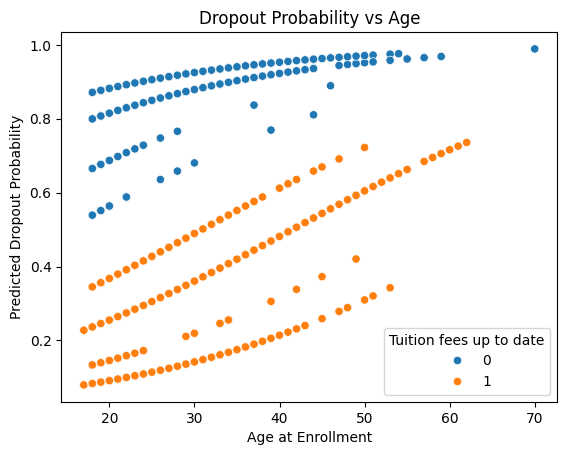

Average effect of tuition being up to date: -0.6125849339840048


In [ ]:
# Predict probabilities
df["pred_prob"] = log_model.predict_proba(X)[:, 1]

# Scatter plot: Age vs probability, colored by tuition status
plt.figure()
sns.scatterplot(
    x=df["Age at enrollment"],
    y=df["pred_prob"],
    hue=df["Tuition fees up to date"]
)
plt.xlabel("Age at Enrollment")
plt.ylabel("Predicted Dropout Probability")
plt.title("Dropout Probability vs Age")
plt.show()

# Average effect of tuition
avg_effect = df[df["Tuition fees up to date"] == 1]["pred_prob"].mean() - \
             df[df["Tuition fees up to date"] == 0]["pred_prob"].mean()

print("Average effect of tuition being up to date:", avg_effect)

In [ ]:
# Predictions
y_pred = log_model.predict(X)

# Confusion matrix and accuracy
cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)

Confusion Matrix:
 [[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


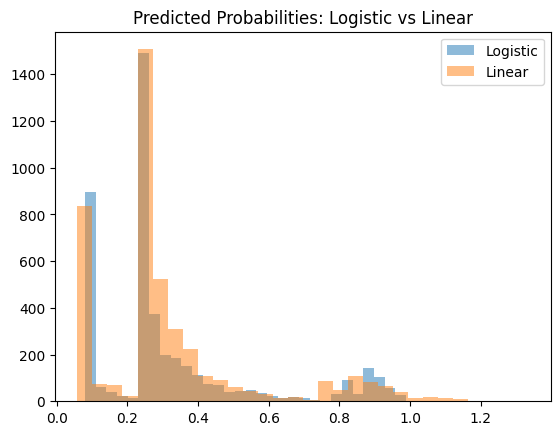

In [ ]:
# Train linear model
lin_model = LinearRegression()
lin_model.fit(X, y)

# Predict "probabilities"
df["lin_pred"] = lin_model.predict(X)

# Histogram comparison
plt.figure()
plt.hist(df["pred_prob"], bins=30, alpha=0.5, label="Logistic")
plt.hist(df["lin_pred"], bins=30, alpha=0.5, label="Linear")
plt.legend()
plt.title("Predicted Probabilities: Logistic vs Linear")
plt.show()

In [ ]:
# Features for multinomial model
X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]

y_multi = df["Target"]

# Train multinomial logistic regression
multi_model = LogisticRegression(max_iter=1000, multi_class='multinomial')
multi_model.fit(X_multi, y_multi)

# Hard predictions
y_multi_pred = multi_model.predict(X_multi)

from sklearn.metrics import confusion_matrix

cm_multi = confusion_matrix(y_multi, y_multi_pred)
print("Multinomial Confusion Matrix:\n", cm_multi)

# Predicted probabilities
multi_probs = multi_model.predict_proba(X_multi)
print("Sample predicted probabilities:\n", multi_probs[:5])

Multinomial Confusion Matrix:
 [[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
Sample predicted probabilities:
 [[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

Rows with missing values were removed using listwise deletion to ensure clean input for the model. The target variable was converted into a binary outcome where alive (C or CL) is 1 and dead (D) is 0, and categorical variables were one-hot encoded.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

The logistic regression results show that higher bilirubin levels are associated with lower survival probability, as indicated by the negative coefficient. Edema also reduces survival, with severe edema (Y) having a stronger negative effect than mild edema (S). The positive coefficient for the placebo variable suggests that patients not receiving the drug may have slightly higher survival, indicating that the drug does not appear to improve survival in this model.

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

The predicted probabilities show that survival decreases as bilirubin increases. From the scatter plot, the difference between drug and placebo groups is relatively small across most bilirubin values, though any effect appears slightly more noticeable at moderate bilirubin levels. On average, the effect of the drug on survival probability is small, indicating only a minor difference between treatment groups.

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

The confusion matrix shows that the model correctly predicts many survival outcomes but makes errors in both classes. The overall accuracy is approximately 73.7%, indicating moderate performance. The model performs reasonably well but is not highly precise in distinguishing between survival and death.

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

The logistic regression model produces probabilities constrained between 0 and 1, while the linear model can generate values outside this range. The histogram shows that logistic predictions are more realistic and better suited for probability estimation. Therefore, logistic regression is more appropriate for modeling survival probabilities.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

The stage prediction model performs poorly in hard classification, as it predicts almost all observations as Stage 3, failing to capture other classes. The confusion matrix shows that several stages are never predicted. However, the predicted probabilities assign nonzero likelihoods to all stages, indicating that the model still captures some information about each class. This suggests that probability outputs are more informative than hard classifications in this case.

In [ ]:
# Load dataset
df = pd.read_csv("cirrhosis.csv")

# Select relevant columns
cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
df = df[cols]

# Drop missing values
df = df.dropna()

# Create binary target: 1 = Alive (C or CL), 0 = Dead (D)
df["Survival"] = df["Status"].apply(lambda x: 1 if x in ["C", "CL"] else 0)

# One-hot encode categorical variables
df = pd.get_dummies(df, columns=["Edema", "Drug"], drop_first=True)

# Features and target
X = df.drop(columns=["Status", "Survival", "Stage"])
y = df["Survival"]

In [ ]:
# Train model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X, y)

# Coefficients
coeffs = pd.Series(log_model.coef_[0], index=X.columns)
print("Logistic Regression Coefficients:\n", coeffs)

Logistic Regression Coefficients:
 Bilirubin      -0.351424
Edema_S        -0.450677
Edema_Y        -1.611049
Drug_Placebo    0.231225
dtype: float64


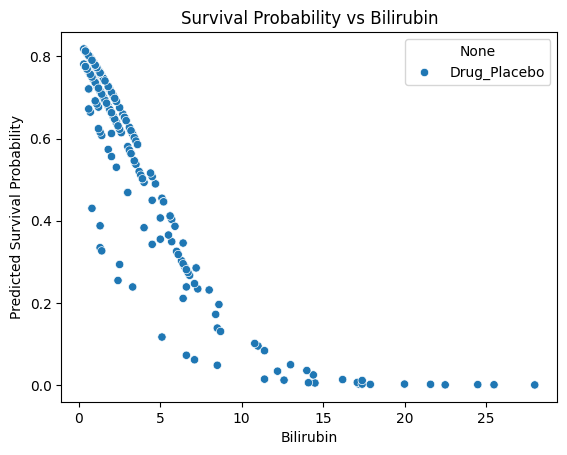

Average effect of drug: 0.018848501038509102


In [ ]:
# Predict probabilities
df["pred_prob"] = log_model.predict_proba(X)[:, 1]

# Scatter plot: Bilirubin vs survival probability, colored by drug
plt.figure()
sns.scatterplot(
    x=df["Bilirubin"],
    y=df["pred_prob"],
    hue=df.filter(like="Drug_").idxmax(axis=1)
)
plt.xlabel("Bilirubin")
plt.ylabel("Predicted Survival Probability")
plt.title("Survival Probability vs Bilirubin")
plt.show()

# Average effect of drug (if Drug column exists after encoding)
drug_cols = [col for col in df.columns if "Drug_" in col]
if drug_cols:
    avg_effect = df[df[drug_cols[0]] == 1]["pred_prob"].mean() - \
                 df[df[drug_cols[0]] == 0]["pred_prob"].mean()
    print("Average effect of drug:", avg_effect)

In [ ]:
# Predictions
y_pred = log_model.predict(X)

# Metrics
cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)

Confusion Matrix:
 [[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


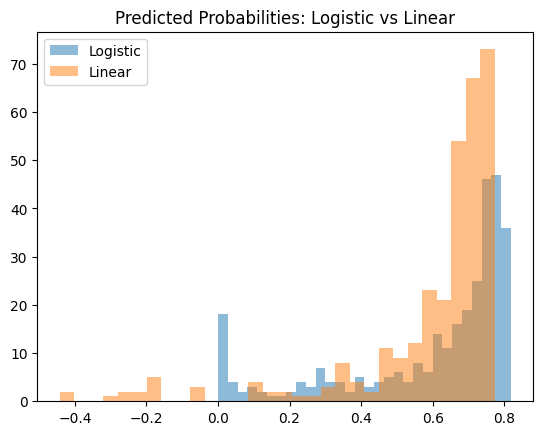

In [ ]:
# Train linear model
lin_model = LinearRegression()
lin_model.fit(X, y)

# Predict
df["lin_pred"] = lin_model.predict(X)

# Histogram comparison
plt.figure()
plt.hist(df["pred_prob"], bins=30, alpha=0.5, label="Logistic")
plt.hist(df["lin_pred"], bins=30, alpha=0.5, label="Linear")
plt.legend()
plt.title("Predicted Probabilities: Logistic vs Linear")
plt.show()

In [ ]:
# Features for stage prediction
X_stage = df[["Bilirubin"] + [col for col in df.columns if "Edema_" in col]]
y_stage = df["Stage"]

# Train model
stage_model = LogisticRegression(max_iter=1000)
stage_model.fit(X_stage, y_stage)

# Hard predictions
y_stage_pred = stage_model.predict(X_stage)

cm_stage = confusion_matrix(y_stage, y_stage_pred)
print("Stage Confusion Matrix:\n", cm_stage)

# Probabilities
stage_probs = stage_model.predict_proba(X_stage)
print("Sample predicted probabilities:\n", stage_probs[:5])

Stage Confusion Matrix:
 [[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]
Sample predicted probabilities:
 [[1.28550372e-05 3.25351316e-02 1.43611431e-01 8.23840583e-01]
 [7.23937578e-02 2.51555267e-01 3.97519699e-01 2.78531276e-01]
 [2.92626485e-02 1.81530850e-01 3.95694470e-01 3.93512032e-01]
 [2.32719781e-02 1.76777228e-01 3.97216502e-01 4.02734292e-01]
 [2.02038998e-02 2.24965391e-01 4.23342268e-01 3.31488440e-01]]


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?